# Lab: Build Neural Networks via Pytorch

The purpose of this assignment is to learn how to build neural networks using PyTorch, focusing on both the theoretical and practical aspects of the process.

One key step involves passing the output of a regression model through the Sigmoid function. This operation transforms the raw output (often called the logit) into a probability value between 0 and 1, which represents the likelihood of an observation belonging to the positive class. 

This step is particularly important in binary classification tasks, as it allows us to interpret the model's predictions in probabilistic terms and enables subsequent evaluation using metrics such as accuracy or binary cross-entropy loss.

## Imports
<hr>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchsummary import summary
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_regression, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

## Neural Network Classification
<hr>

### 1. Binary Classification

We will build a binary classification model using PyTorch. The output of the regression model will be passed through the Sigmoid function to convert it into a value between 0 and 1, representing the probability that an observation belongs to the positive class.

#### PyTorch Tensor

Please convert your input data, X (features) and y (labels), into PyTorch tensors so they can be used with PyTorch models.

X_t and y_t are created as tensors with the data type torch.float32, which is required for most machine learning tasks in PyTorch.

In [9]:
X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=2020)


# Your code for tensor
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)


#### TensorDataset
Use PyTorch's TensorDataset and DataLoader to prepare the dataset for training, including batching and shuffling.

Requirements:

Combine X_t and y_t into a dataset using TensorDataset.

Use DataLoader to create batches of data for training. The batch size should be specified by the variable 45.
Enable shuffle=True in the DataLoader to randomize the order of data for each epoch.

In [14]:
# Create dataloader
# Your code for TensorDataset and dataloader
batchSize = 45

dataset = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size=batchSize, shuffle=True)

#### Visualize your circular dataset

Visualize your circular dataset with the following requirements:

- The figure size should be set to 5×5.
- Data points with y = 0 should be marked in blue, and those with y = 1 should be marked in red.
- Both the x-axis and y-axis labels should have a font size of 14.

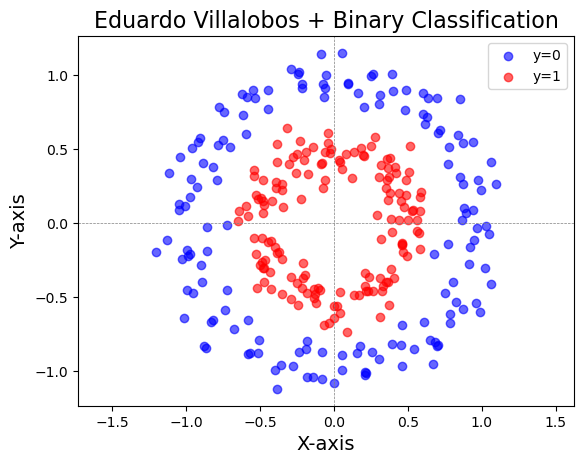

In [27]:

# Plot each class
# Your code plot with scatter

# Add Label and title
plt.title("Eduardo Villalobos + Binary Classification", fontsize=16)
# Your code set graph axises
for X_batch, y_batch in dataloader:
    plt.scatter(X_batch[y_batch == 0][:, 0], X_batch[y_batch == 0][:, 1], color='blue', alpha=0.6, label="y=0" if 'y=0' not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.scatter(X_batch[y_batch == 1][:, 0], X_batch[y_batch == 1][:, 1], color='red', alpha=0.6, label="y=1" if 'y=1' not in plt.gca().get_legend_handles_labels()[1] else "")
    
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("X-axis", fontsize=14)
plt.ylabel("Y-axis", fontsize=14)
plt.legend()
plt.axis("equal")

# Show the plot
plt.show()

We're going to start using `ReLU` as our activation function(s) and `Adam` as our optimizer because these are what are currently, commonly used in practice. We are doing classification now so we'll need to use log loss (binary cross entropy) as our loss function:

$$f(w) = \sum_{x,y \in D} -y log(\hat{y}) - (1-y)log(1-\hat{y})$$

#### Create Neural Network 

Implement a neural network class for binary classification using PyTorch's nn.Module.

- Create a fully connected layer that maps the input features to the hidden layer.
- Use Relu as activation
- Create another fully connected layer
- Use Sigmoid


In [31]:

class binaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.main = nn.Sequential(
            # Your code 
            torch.nn.Linear(input_size, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Sigmoid(),                        
            torch.nn.Linear(hidden_size, output_size)  
        
        )

    def forward(self, x):
        out = self.main(x)
        return out

#### Build trainer

Implement a simple training wrapper for a PyTorch network that handles the forward pass, backpropagation, and parameter updates for multiple epochs.

Training Process:

Epoch Loop: 
- Iterate over the specified number of epochs.

Batch Loop:
- Iterate over batches of X and y from the dataloader.
- Clear the gradients using optimizer.zero_grad().
- Perform a forward pass:
- Use the model to compute predictions (y_hat).
- Flatten the output to match the expected shape if necessary.
- Calculate the loss using criterion(y_hat, y).
- Perform backpropagation with loss to compute gradients.
- Update model parameters using optimizer.step().
- Accumulate the loss for the batch into a running total.

Logging:
- At the end of each epoch, compute and print the average loss over all batches if verbose is True.

In [132]:
def trainer(model, criterion, optimizer, dataloader, epochs=5, verbose=True):
    # You may review the ipynb file from Week 6
    # Your code
    train_losses = []
    for epoch in range(epochs):
        losses = 0
        model.train()
        for X, y in dataloader:
            optimizer.zero_grad()        # Clear gradients w.r.t. parameters
            y_hat = model(X).flatten()       # Forward pass to get output
            loss = criterion(y_hat,y)        # Calculate loss
            loss.backward()         # Getting gradients w.r.t. parameters
            optimizer.step()            # Update parameters
            losses += loss.item()       # Add loss for this batch to running total
        train_losses.append(losses/len(dataloader))
        if verbose: print(f"epoch: {epoch + 1}, loss: {losses / len(dataloader):.4f}")
    results = train_losses
    return results

In PyTorch, the binary cross entropy loss criterion is `torch.nn.BCELoss`. The formula expects a "probability" which is why we add a Sigmoid function to the end of out network.

In [136]:
LEARNING_RATE = 0.1
# Your code
# set your mode with 2 input layers, 6 hidden layers, and 1 output layers via binaryClassifier class
model = binaryClassifier(2,6,1)
criterion =  nn.BCEWithLogitsLoss()  # loss function - binary cross entropy loss
optimizer =  optim.Adam(model.parameters()) # optimization algorithm - Adam

Let's train the model:

In [139]:
results = trainer(model,criterion,optimizer,dataloader, epochs=5, verbose=True)

epoch: 1, loss: 0.6989
epoch: 2, loss: 0.6981
epoch: 3, loss: 0.6959
epoch: 4, loss: 0.6956
epoch: 5, loss: 0.6951


#### Activation functions

We're going to using `ReLU` as our activation function(s) and `Adam` as our optimizer because these are what are currently, commonly used in practice. We are doing classification now so we'll need to use log loss (binary cross entropy) as our loss function:

$$f(w) = \sum_{x,y \in D} -y log(\hat{y}) - (1-y)log(1-\hat{y})$$

In PyTorch, the binary cross entropy loss criterion is `torch.nn.BCELoss`. The formula expects a "probability" which is why we add a Sigmoid function to the end of out network.

In [142]:
LEARNING_RATE = 0.1
criterion = torch.nn.BCEWithLogitsLoss() # loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)  # optimization algorithm

In [144]:
# build your trainer funtion with model, criterion, optimizer, dataloader, epochs=30, verbose=True
# Your code
results = trainer(model,criterion,optimizer,dataloader, epochs=30, verbose=True)


epoch: 1, loss: 0.7154
epoch: 2, loss: 0.6954
epoch: 3, loss: 0.6928
epoch: 4, loss: 0.7001
epoch: 5, loss: 0.6911
epoch: 6, loss: 0.6859
epoch: 7, loss: 0.6799
epoch: 8, loss: 0.6603
epoch: 9, loss: 0.6634
epoch: 10, loss: 0.6473
epoch: 11, loss: 0.6378
epoch: 12, loss: 0.6378
epoch: 13, loss: 0.6198
epoch: 14, loss: 0.6064
epoch: 15, loss: 0.5911
epoch: 16, loss: 0.5841
epoch: 17, loss: 0.5716
epoch: 18, loss: 0.5531
epoch: 19, loss: 0.5481
epoch: 20, loss: 0.5304
epoch: 21, loss: 0.5320
epoch: 22, loss: 0.5182
epoch: 23, loss: 0.4925
epoch: 24, loss: 0.4822
epoch: 25, loss: 0.4686
epoch: 26, loss: 0.4620
epoch: 27, loss: 0.4458
epoch: 28, loss: 0.4262
epoch: 29, loss: 0.4266
epoch: 30, loss: 0.4074


#### Visualize your results 

#### Part 1: Loss Curve

- Please plot the loss curve during training.
- Your graph needs to be labeled with x-axis, y-axis, and title.
- The title needs to include your first name.
- Your graph needs to have a legend and a grid.

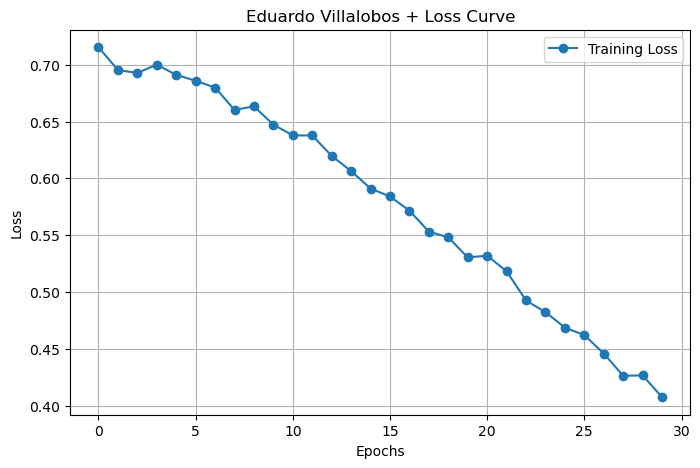

In [149]:
# Your code 
train_loss = results      # Training loss per epoch


# Plot Training and Validation Loss Curve
plt.figure(figsize=(8, 5))  # Set the figure size
plt.plot(train_loss, label="Training Loss", marker='o')  # Training loss
plt.xlabel("Epochs")  # X-axis label
plt.ylabel("Loss")  # Y-axis label
plt.title("Eduardo Villalobos + Loss Curve")  # Plot title
plt.legend()  # Add a legend
plt.grid()  # Add grid lines for better readability
plt.show()

### Part 2: Actual and predicted data 

- Please plot the Actual and predicted data after training.
- Your graph needs to be labeled with x-axis, y-axis, and title.
- The title needs to include your first name.
- Your graph needs to have a legend and a grid.

In [163]:
# Your code


To be clear, our model is just outputting some number between -1 and +1 (we are applying Sigmoid in the model), so:
- To get the probabilities we would need to pass them through a Sigmoid;
- To get classes, we can apply some threshold (usually 0.5) to this probability.

For example, we would expect the point (0,0) to have a high probability and the point (-1,-1) to have a low probability:

In [169]:
#prediction = 
#print(prediction)

In [ ]:
probability = # you code
print(probability)

In [ ]:
classes = np.where(probability > 0.5, 1, 0)
print(classes)

### 2. Multiclass Classification

For multiclass classification, we'll need the softmax function:

$$\sigma(\vec{z})_i=\frac{e^{z_i}}{\sum_{j=1}^{K}e^{z_j}}$$

It basically outputs probabilities for each class we wish to predict, and they all sum to 1. 

`torch.nn.CrossEntropyLoss` is a loss that combines a softmax with cross entropy loss. 

Let's try a 4-class classification problem using the following network:


In [171]:
X, y = make_blobs(n_samples=200, centers=4, center_box=(-1.2, 1.2), cluster_std=[0.15, 0.15, 0.15, 0.15], random_state=12345)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# Create dataloader
dataset = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size=batchSize, shuffle=True)

In [173]:
class multiClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.main = torch.nn.Sequential(
            torch.nn.Linear(input_size, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        out = self.main(x)
        return out

#### Visualize your circular dataset

Visualize your circular dataset with the following requirements:

- The figure size should be set to 5×5.
- Both the x-axis and y-axis labels should have a font size of 14.

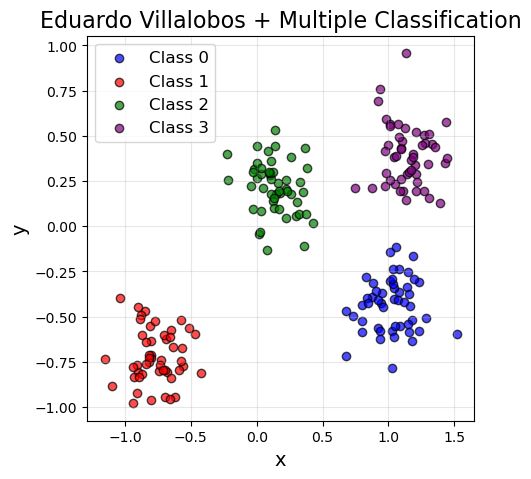

In [182]:
# Plot each class
# Your code plot with scatter

# Add Label and title
# Your code 
plt.figure(figsize = (5,5))
colors = ['blue', 'red', 'green', 'purple']
for X_batch, y_batch in dataloader:
    for i in range(4):
        mask = y_batch == i  # Select points of class i
        plt.scatter(X_batch[mask][:, 0], X_batch[mask][:, 1], color=colors[i], edgecolors='k', alpha=0.7, label=f"Class {i}" if f"Class {i}" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("Eduardo Villalobos + Multiple Classification", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Let's train this model:

In [196]:
# model with 2 input layers, 6 hidden layers, and 4 output layers via multiClassifier class
# Your code 
model_2 = multiClassifier(2,6,4)

# Your code 
criterion = torch.nn.CrossEntropyLoss()# loss function with CrossEntropyLoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.2)# optimization algorithm - Adam lr=0.2
train_losses, train_accuracy = [],[]
for epoch in range(10):
    losses = 0
    acc = 0
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()        # Clear gradients w.r.t. parameters
        y_hat = model(X_batch).flatten() # Forward pass to get output
        y_hat_labels = torch.sigmoid(y_hat) > 0.5 #sigmoid activation and classify outputs
        loss = criterion(y_hat,y_batch)        # Calculate loss
        loss.backward()         # Getting gradients w.r.t. parameters
        optimizer.step()            # Update parameters
        losses += loss.item()       # Add loss for this batch to running total
        acc += (y_hat_labels == y_batch).type(torch.float32).mean().item()
    train_losses.append(losses/len(dataloader))
    train_accuracy.append(acc/len(dataloader))
    print(f"epoch: {epoch + 1}, loss: {losses / len(dataloader):.4f}")
results = {"train_loss": train_losses,
           "train_accuracy": train_accuracy}

epoch: 1, loss: 204.1044
epoch: 2, loss: 201.2514
epoch: 3, loss: 202.2815
epoch: 4, loss: 202.6300
epoch: 5, loss: 202.0265
epoch: 6, loss: 202.3108
epoch: 7, loss: 201.7364
epoch: 8, loss: 201.2540
epoch: 9, loss: 200.9149
epoch: 10, loss: 202.0282


#### Visualize your results 

### Part 3: Accuracy Curve for 4 classes

- Please plot the Accuracy Curve during training.
- Your graph needs to be labeled with x-axis, y-axis, and title.
- The title needs to include your first name.
- Your graph needs to have a legend and a grid.

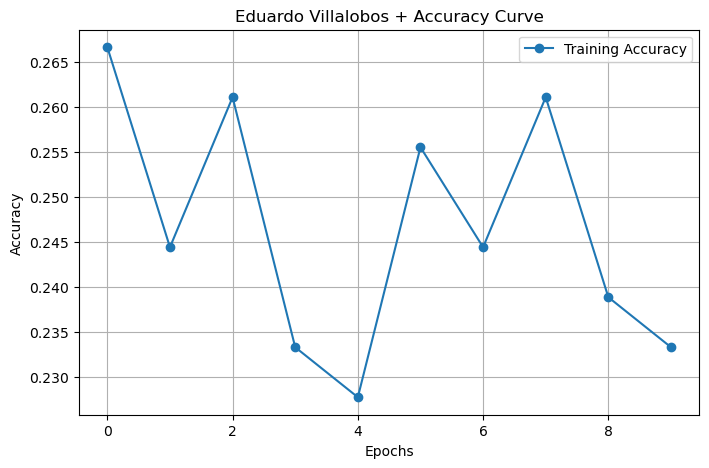

In [198]:
# Your code
train_accuracy = results["train_accuracy"]      # Training Accuracy per epoch


# Plot Training and Validation Loss Curve
plt.figure(figsize=(8, 5))  # Set the figure size
plt.plot(train_accuracy, label="Training Accuracy", marker='o')  # Training loss
plt.xlabel("Epochs")  # X-axis label
plt.ylabel("Accuracy")  # Y-axis label
plt.title("Eduardo Villalobos + Accuracy Curve")  # Plot title
plt.legend()  # Add a legend
plt.grid()  # Add grid lines for better readability
plt.show()

### Part 4: Actual and predicted data for classes

- Please plot the Actual and predicted data after training.
- Your graph needs to be labeled with x-axis, y-axis, and title.
- The title needs to include your first name.
- Your graph needs to have a legend and a grid.

In [ ]:
# Your code